# OTAlign 모델을 이용한 단백질 서열 정렬 예제

이 노트북은 학습된 OTAlign 모델을 불러와 두 개의 단백질 서열을 정렬하는 과정을 보여줍니다.

**참고:** 이 노트북을 실행하려면 먼저 모델을 학습하고 유효한 체크포인트 경로를 `checkpoint_path` 변수에 지정해야 합니다. 현재는 모델이 없으므로 코드 실행 시 오류가 발생합니다.

## 1. 필요한 라이브러리 임포트

In [1]:
from pathlib import Path

import matplotlib as mpl
import numpy as np
import torch
import yaml

# OTAlign 프로젝트의 주요 컴포넌트들을 임포트합니다.
from otalign.align.cost import pairwise_cosine
from otalign.align.uot_alignment import hard_alignment_from_transport
from otalign.functional.sinkhorn_uot import unbalanced_sinkhorn
from otalign.models.plm_adaptors import get_plm_adaptor_and_configs
from otalign.utils.checkpointing import load_peft_model_from_checkpoint
from otalign.utils.display import print_alignment
from otalign.viz import plot_plan_with_domains

## 2. 설정 및 모델 로드

학습 시 사용했던 설정 파일과 모델 체크포인트 경로를 지정합니다. **`checkpoint_path`를 실제 학습된 모델의 경로로 수정해야 합니다.**

In [2]:
# 학습 설정 파일 경로
config_path = "configs/train_config.yaml"

# 모델 체크포인트 경로 (!!! 중요: 실제 경로로 수정 필요 !!!)
# 예: 'trainer_output/your_run_name/checkpoint-epoch-10'
# checkpoint_path = "AnkhCL"
checkpoint_path = "work/checkpoints/esm1b-lora-finetune-2/checkpoint-epoch-3"

with open(config_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# PLM 어댑터와 모델을 로드합니다.
plm_adaptor, _, _ = get_plm_adaptor_and_configs(config["model_name"], for_masked_lm=True)
model = plm_adaptor.model

# 체크포인트에서 LoRA 가중치를 로드합니다.
if Path(checkpoint_path).exists():
    lora_model = load_peft_model_from_checkpoint(model, checkpoint_path)
    lora_model.to(device)
    lora_model.eval()
    plm_adaptor.model = lora_model
    print(f"Model loaded from {checkpoint_path}")
else:
    print(f"[경고] 체크포인트 파일을 찾을 수 없습니다: {checkpoint_path}")
    lora_model = None
    model.to(device)
    model.eval()

Using device: cuda
Model loaded from work/checkpoints/esm1b-lora-finetune-2/checkpoint-epoch-3


## 3. 정렬할 단백질 서열 정의

In [3]:
# 예제 단백질 서열
seq1 = "AGLPVIMCLKSNNHQKYLRYQSDNIQQYGLLQFSADKILDPLAQFEVEPSKTY"
seq2 = "DGLVHIKSRYTNKYLVRWSPNHYWITASANEPDENKSNWACTLFKPLYVEEGN"

## 4. 서열 임베딩 및 비용 행렬 계산

In [4]:
def get_embeddings(sequence, adaptor, device):
    # 모델이 로드되지 않았으면 더미 데이터를 반환합니다.
    if adaptor.model is None:
        return torch.randn(1, len(sequence), 1280).to(device), torch.tensor([len(sequence)]).to(device)

    with torch.no_grad():
        # OTAlignCollator와 유사하게 입력을 준비합니다.
        # 실제로는 배치를 고려해야 하지만, 여기서는 단일 서열을 처리합니다.
        emb_out = adaptor.encode([sequence], device=device, disable_grad=True)
        return emb_out.residue_embeddings, torch.tensor([len(sequence)]).to(device)


emb1, len1 = get_embeddings(seq1, plm_adaptor, device)
emb2, len2 = get_embeddings(seq2, plm_adaptor, device)

# 임베딩으로부터 비용 행렬(코사인 거리)을 계산합니다.
cost_matrix = pairwise_cosine(emb1, emb2)

print(f"Sequence 1 length: {len1.item()}")
print(f"Sequence 2 length: {len2.item()}")
print(f"Cost matrix shape: {cost_matrix.shape}")

Sequence 1 length: 53
Sequence 2 length: 53
Cost matrix shape: torch.Size([1, 53, 53])


## 5. Unbalanced Optimal Transport (Sinkhorn 알고리즘) 실행

계산된 비용 행렬을 기반으로 두 서열 간의 최적의 정렬(transport plan)을 찾습니다.

In [5]:
config["uot"]["reg_m"] = 1.0


B, N, M = cost_matrix.shape
lens1, lens2 = len1.to(device), len2.to(device)

# 마스크 및 주변 확률 분포(marginal probability distributions) a, b를 생성합니다.
mask1 = torch.arange(N, device=device)[None, :] < lens1[:, None]
mask2 = torch.arange(M, device=device)[None, :] < lens2[:, None]
a = mask1.float() / lens1[:, None].clamp(min=1).float()
b = mask2.float() / lens2[:, None].clamp(min=1).float()

# 마스크 밖의 비용을 매우 높게 설정합니다.
cost_matrix[~(mask1[:, :, None] * mask2[:, None, :])] = 1e6

# UOT Sinkhorn 알고리즘을 실행하여 transport plan을 얻습니다.
transport_plan, u, v = unbalanced_sinkhorn(
    cost_matrix,
    a,
    b,
    config["uot"]["num_iter"],
    config["uot"]["reg"],
    config["uot"]["reg_m"],
    config["uot"]["reg_m"],
    mask_a=mask1,
    mask_b=mask2,
)

print(f"Transport plan shape: {transport_plan.shape}")

Transport plan shape: torch.Size([1, 53, 53])


## 6. 정렬 결과 시각화

계산된 transport plan을 히트맵으로 시각화하여 두 서열 간의 정렬 관계를 확인합니다.

<pre style='font-family: monospace; line-height: 1.2;'>Query            (1-53) : agl<span style="color: rgb(162,218,55);">P</span><span style="color: rgb(205,224,29);">V</span><span style="color: rgb(225,227,24);">I</span><span style="color: rgb(228,227,24);">M</span><span style="color: rgb(233,228,25);">C</span><span style="color: rgb(241,229,28);">L</span><span style="color: rgb(241,229,28);">K</span><span style="color: rgb(243,229,30);">S</span><span style="color: rgb(248,230,33);">N</span><span style="color: rgb(246,230,31);">N</span><span style="color: rgb(250,230,34);">H</span><span style="color: rgb(250,230,34);">Q</span><span style="color: rgb(250,230,34);">K</span><span style="color: rgb(253,231,36);">Y</span><span style="color: rgb(250,230,34);">L</span><span style="color: rgb(250,230,34);">R</span><span style="color: rgb(248,230,33);">Y</span><span style="color: rgb(243,229,30);">Q</span><span style="color: rgb(241,229,28);">S</span><span style="color: rgb(228,227,24);">D</span><span style="color: rgb(207,225,28);">N</span>IQQ<span style="color: rgb(210,225,27);">Y</span><span style="color: rgb(236,228,26);">G</span><span style="color: rgb(238,229,27);">L</span><span style="color: rgb(233,228,25);">L</span><span style="color: rgb(236,228,26);">Q</span><span style="color: rgb(238,229,27);">F</span><span style="color: rgb(238,229,27);">S</span><span style="color: rgb(233,228,25);">A</span><span style="color: rgb(228,227,24);">D</span><span style="color: rgb(191,223,36);">K</span>-----<span style="color: rgb(178,221,44);">I</span><span style="color: rgb(218,226,24);">L</span><span style="color: rgb(223,227,24);">D</span><span style="color: rgb(246,230,31);">P</span><span style="color: rgb(248,230,33);">L</span><span style="color: rgb(250,230,34);">A</span><span style="color: rgb(250,230,34);">Q</span><span style="color: rgb(253,231,36);">F</span><span style="color: rgb(253,231,36);">E</span><span style="color: rgb(250,230,34);">V</span><span style="color: rgb(250,230,34);">E</span><span style="color: rgb(248,230,33);">P</span><span style="color: rgb(248,230,33);">S</span><span style="color: rgb(241,229,28);">K</span><span style="color: rgb(236,228,26);">T</span><span style="color: rgb(223,227,24);">Y</span>-<br>                        :    ..++.+::....:::...:.:   +..+..::++     .......:+....+.. <br>Templ            (1-53) : ---<span style="color: rgb(162,218,55);">D</span><span style="color: rgb(205,224,29);">G</span><span style="color: rgb(225,227,24);">L</span><span style="color: rgb(228,227,24);">V</span><span style="color: rgb(233,228,25);">H</span><span style="color: rgb(241,229,28);">I</span><span style="color: rgb(241,229,28);">K</span><span style="color: rgb(243,229,30);">S</span><span style="color: rgb(248,230,33);">R</span><span style="color: rgb(246,230,31);">Y</span><span style="color: rgb(250,230,34);">T</span><span style="color: rgb(250,230,34);">N</span><span style="color: rgb(250,230,34);">K</span><span style="color: rgb(253,231,36);">Y</span><span style="color: rgb(250,230,34);">L</span><span style="color: rgb(250,230,34);">V</span><span style="color: rgb(248,230,33);">R</span><span style="color: rgb(243,229,30);">W</span><span style="color: rgb(241,229,28);">S</span><span style="color: rgb(228,227,24);">P</span><span style="color: rgb(207,225,28);">N</span>---<span style="color: rgb(210,225,27);">H</span><span style="color: rgb(236,228,26);">Y</span><span style="color: rgb(238,229,27);">W</span><span style="color: rgb(233,228,25);">I</span><span style="color: rgb(236,228,26);">T</span><span style="color: rgb(238,229,27);">A</span><span style="color: rgb(238,229,27);">S</span><span style="color: rgb(233,228,25);">A</span><span style="color: rgb(228,227,24);">N</span><span style="color: rgb(191,223,36);">E</span>PDENK<span style="color: rgb(178,221,44);">S</span><span style="color: rgb(218,226,24);">N</span><span style="color: rgb(223,227,24);">W</span><span style="color: rgb(246,230,31);">A</span><span style="color: rgb(248,230,33);">C</span><span style="color: rgb(250,230,34);">T</span><span style="color: rgb(250,230,34);">L</span><span style="color: rgb(253,231,36);">F</span><span style="color: rgb(253,231,36);">K</span><span style="color: rgb(250,230,34);">P</span><span style="color: rgb(250,230,34);">L</span><span style="color: rgb(248,230,33);">Y</span><span style="color: rgb(248,230,33);">V</span><span style="color: rgb(241,229,28);">E</span><span style="color: rgb(236,228,26);">E</span><span style="color: rgb(223,227,24);">G</span>n</pre>

Alignment length       : 59
Aligned positions      : 47
Identical matches      : 10
Conservative matches   : 9
Non-conservative       : 28
Gaps                   : 8
Identity               : 21.28%
Similarity (cons.)     : 40.43%


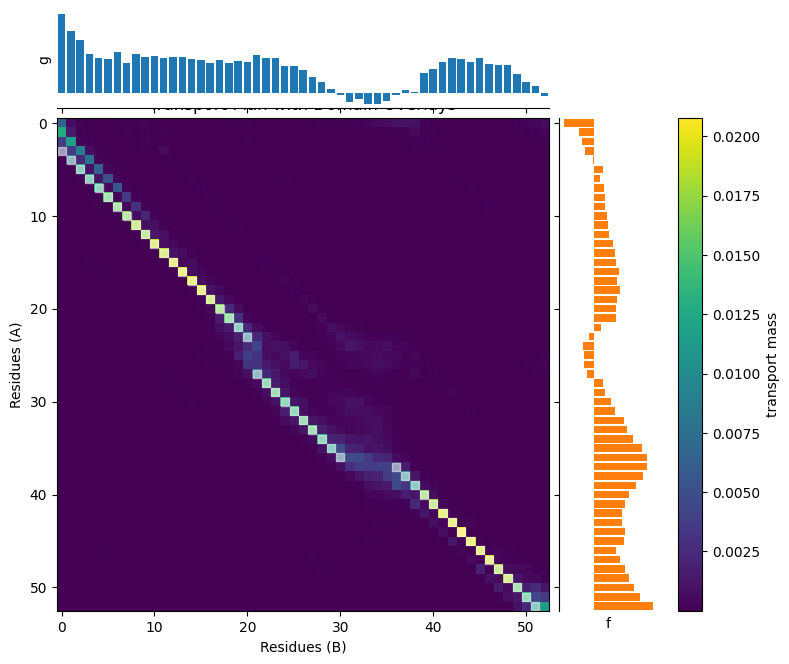

In [6]:
plan = transport_plan[0].cpu().numpy()
f = np.log(u[0].cpu().numpy())
g = np.log(v[0].cpu().numpy())
s = np.log(plan)


aln_dict = hard_alignment_from_transport(plan, mode="glocal")
matches = np.array([(x - 1, y - 1) for x, y, o in aln_dict["path"] if o == "M"])
print_alignment(seq1, seq2, aln_dict["path"], score=s, cmap=mpl.colormaps["viridis"], display_mode="global_view")


gamma = 1.0
fig, ax = plot_plan_with_domains(plan**gamma, f=-f, g=-g)
ax.scatter(matches[:, 1], matches[:, 0], marker="s", color="w", alpha=0.5)
fig.set_figwidth(8)
fig.set_figheight(8)
ax.set_aspect("equal")
fig.tight_layout()
fig.show()